<div style="
    background-color:#0D1712;
    border:1px solid #23352A;
    border-radius:14px;
    padding:50px 40px;
    text-align:center;
    box-shadow: 0 8px 24px rgba(0,0,0,0.25);
    font-family: 'Helvetica Neue', Arial, sans-serif;
    margin-bottom: 30px;
">

<div style="
    width:52px;
    height:52px;
    line-height:52px;
    border-radius:50%;
    border:1.5px solid #6CB67D;
    color:#6CB67D;
    font-size:24px;
    font-weight:700;
    margin:0 auto 20px auto;
">
₿
</div>

<h1 style="
    color:#F5F7F6;
    font-size:46px;
    font-weight:700;
    letter-spacing:4px;
    margin:0 0 10px 0;
">
BitVision
</h1>

<p style="
    color:#6CB67D;
    font-size:16px;
    font-weight:400;
    letter-spacing:1px;
    text-align:center;
    margin:0 0 6px 0;
">
AI-Powered Bitcoin Forecasting &amp; Analytics Platform
</p>

<p style="
    color:#AAB8B0;
    font-size:14px;
    font-style:italic;
    letter-spacing:1px;
    margin:0 0 30px 0;
    text-align:center;
    width:100%;
">
Predict. Visualize. Decide. Master the crypto candles with AI.
</p>

<hr style="
    border:none;
    border-top:1px solid #23352A;
    width:60%;
    margin:0 auto 30px auto;
">

<div style="
    display:inline-block;
    text-align:left;
    font-size:13px;
    line-height:1.9;
">

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Version</span>
<span style="color:#F5F7F6;">v3.0 AI Engine</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Notebook</span>
<span style="color:#F5F7F6;">04_XGBoost.ipynb</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Author</span>
<span style="color:#F5F7F6;">Team BitVision</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px; vertical-align:top;">Tech Stack</span>
<span style="color:#F5F7F6;">Python • Pandas • NumPy • Scikit-learn • Matplotlib • Seaborn • Joblib</span>
</div>

</div>

</div>

# INTRODUCTION

Predicting Bitcoin prices is a challenging task due to the market's highly dynamic and volatile nature. Traditional approaches that predict raw prices with tree-based models fail because these models **cannot extrapolate** beyond their training range.

This notebook addresses that fundamental limitation by predicting **percentage returns** instead of raw prices. Returns are stationary (typically bounded between -10% and +10% regardless of whether Bitcoin is at \$300 or \$100,000), eliminating the extrapolation problem entirely.

Additionally, all input features have been designed to be **scale-independent** — using rates of change, volatility ratios, and normalised indicators instead of raw price levels. This ensures the model generalises across different price regimes.

The trained model will be compared with Random Forest, CatBoost, Prophet, and LSTM in the final model comparison to identify the most effective forecasting approach for the BitVision platform.


# OBJECTIVES

The objectives of this notebook are to:

- Understand the working principles of the XGBoost Regression algorithm.
- Engineer **stationary, scale-independent** features for model input.
- Create the target variable as **next-day percentage return** instead of raw price.
- Train an XGBoost Regression model on return-based features.
- Convert predicted returns back to dollar prices for interpretable evaluation.
- Evaluate model performance using multiple regression metrics.
- Visualise prediction performance and feature importance.
- Save the trained model for deployment within the BitVision platform.


# BUSINESS UNDERSTANDING

Bitcoin is one of the world's most volatile financial assets, making short-term price forecasting both commercially valuable and technically challenging. Traders, portfolio managers, and automated systems require reliable next-day price estimates for position sizing, risk management, and algorithmic execution.

XGBoost (Extreme Gradient Boosting) is one of the most widely adopted algorithms for structured data prediction. Unlike Random Forest, which combines independently trained Decision Trees through averaging, XGBoost builds trees **sequentially** — each new tree is specifically designed to correct the prediction errors of the previous trees. This iterative error-correction strategy often produces higher predictive accuracy on complex datasets.

This notebook applies XGBoost to next-day Bitcoin return prediction using stationary, scale-independent features.


# UNDERSTANDING XGBoost
XGBoost (Extreme Gradient Boosting) is an advanced ensemble machine learning algorithm designed to improve prediction accuracy by sequentially combining multiple Decision Trees.

Unlike Random Forest, where Decision Trees are built independently, XGBoost trains one tree at a time. Each new tree focuses on correcting the prediction errors made by the previous trees, gradually improving the overall model performance.

This boosting strategy enables XGBoost to capture complex nonlinear relationships while maintaining high computational efficiency and robustness, making it one of the most widely used algorithms for regression and classification problems.

## How does XGBoost work?
XGBoost improves predictions through the following iterative process:

1. Train the first Decision Tree using the training dataset.
2. Calculate the prediction errors made by the model.
3. Train a new Decision Tree specifically to reduce those errors.
4. Repeat the process by sequentially adding more trees.
5. Combine the predictions from all trees to produce the final output.

By continuously learning from previous mistakes, XGBoost gradually minimizes prediction errors and builds a more accurate forecasting model.

## XGBoost Workflow
Training Data<br>
      │<br>
      ▼<br>
Decision Tree 1<br>
      │<br>
Prediction Errors<br>
      │<br>
      ▼<br>
Decision Tree 2<br>
(Corrects Errors)<br>
      │<br>
Prediction Errors<br>
      │<br>
      ▼<br>
Decision Tree 3<br>
(Corrects Remaining Errors)<br>
      │<br>
      ▼<br>
Final Prediction<br>

## Random Forest vs XGBoost
| Random Forest | XGBoost |
|---------------|----------|
| Trees are built independently. | Trees are built sequentially. |
| Final prediction is obtained by averaging all trees. | Each new tree corrects the errors of previous trees. |
| Faster training with strong baseline performance. | Higher predictive accuracy through boosting. |
| May struggle with complex error correction. | Continuously reduces prediction errors during training. |

# IMPORTING LIBRARIES

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## Validation

In [2]:
print("Libraries imported successfully.")

Libraries imported successfully.


## Observation

All the required libraries have been successfully imported and the environment is ready for implementing the XGBoost Regression model.

# LOAD DATASET

Loading the feature-engineered Bitcoin dataset created in Notebook 02.


In [3]:
df = pd.read_csv("bitcoin_feature_engineered.csv")
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Lag_1,Lag_3,Lag_7,...,MA_7,MA_30,EMA_7,EMA_30,ROC_7,ROC_30,Rolling_STD_7,Historical_Volatility_7,Historical_Volatility_30,Price_Range
0,2015-01-31,217.464005,233.503998,216.309006,226.440994,23348200.0,-0.039576,226.425003,233.914993,247.847000,...,243.140429,246.600333,233.475314,249.197910,-0.122588,-0.307988,20.663675,1.130806,1.432069,17.194992
1,2015-02-01,226.972000,231.574005,212.014999,216.867004,29128500.0,0.043722,217.464005,233.513000,253.718002,...,239.319571,243.664999,231.849486,247.763980,-0.105416,-0.279527,20.853717,1.182698,1.443543,19.559006
2,2015-02-02,238.229004,242.175003,222.658997,226.490997,30612100.0,0.049596,226.972000,226.425003,273.472992,...,234.284716,242.236566,233.444365,247.148820,-0.128876,-0.152457,14.528994,1.060246,1.410634,19.516006
3,2015-02-03,227.268005,245.957001,224.483002,237.453995,40783700.0,-0.046010,238.229004,217.464005,263.475006,...,229.112287,241.005666,231.900275,245.866187,-0.137421,-0.139772,6.787648,1.072353,1.404277,21.473999
4,2015-02-04,226.852997,230.057999,221.113007,227.511002,26594300.0,-0.001826,227.268005,226.972000,233.914993,...,228.103431,239.418299,230.638456,244.639530,-0.030190,-0.173499,6.472337,0.735168,1.396405,8.944992


## Observation

The feature-engineered Bitcoin dataset has been successfully loaded. The CSV includes several **stationary features** (ROC_7, ROC_30, Historical_Volatility_7, Historical_Volatility_30) that are critical for the return-based prediction approach used in this notebook.


# DATASET OVERVIEW
Before training the model, it is important to verify the dataset structure and confirm that all engineered features have been loaded correctly.

This helps ensure data consistency before proceeding with model development.

In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (4008, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4008 entries, 0 to 4007
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      4008 non-null   object 
 1   Close                     4008 non-null   float64
 2   High                      4008 non-null   float64
 3   Low                       4008 non-null   float64
 4   Open                      4008 non-null   float64
 5   Volume                    4008 non-null   float64
 6   Daily_Return              4008 non-null   float64
 7   Lag_1                     4008 non-null   float64
 8   Lag_3                     4008 non-null   float64
 9   Lag_7                     4008 non-null   float64
 10  Lag_30                    4008 non-null   float64
 11  MA_7                      4008 non-null   float64
 12  MA_30                     4008 non-null   float64
 13  EMA_7                     4008 non-nu

In [5]:
df.describe()

,Close,High,Low,Open,Volume,Daily_Return,Lag_1,Lag_3,Lag_7,Lag_30,MA_7,MA_30,EMA_7,EMA_30,ROC_7,ROC_30,Rolling_STD_7,Historical_Volatility_7,Historical_Volatility_30,Price_Range
count,4008.000000,4008.000000,4008.000000,4008.000000,4.008000e+03,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000,4008.000000
mean,28074.596506,28614.761507,27460.889110,28053.677161,2.244165e+10,0.002095,28052.619340,28006.281866,27910.955758,27397.011915,28005.662251,27742.250630,28005.572020,27743.670139,0.014802,0.067983,800.099910,0.561150,0.605429,1153.872397
std,32044.157083,32574.368501,31457.055192,32033.735039,2.290694e+10,0.034694,32033.038303,32006.062285,31946.239641,31664.903289,31983.279820,31760.065454,31972.529516,31706.926206,0.094448,0.231351,982.148961,0.352416,0.277420,1547.093311
min,210.494995,221.807007,199.567001,210.067993,1.060090e+07,-0.371695,210.494995,210.494995,210.494995,178.102997,221.382429,225.519800,222.076523,231.205045,-0.452482,-0.603168,1.106973,0.038175,0.135548,1.028000
25%,3857.612549,3926.816284,3767.402954,3854.455627,2.937200e+09,-0.012097,3856.669556,3853.530273,3841.825317,3660.435608,3847.880249,3773.833537,3850.702268,3862.473953,-0.033116,-0.073050,88.228178,0.317039,0.411958,105.673340
50%,11564.331543,11850.328613,11288.414062,11536.727539,1.809715e+10,0.001237,11548.931641,11518.089355,11490.100098,11322.661621,11536.751535,11147.956185,11512.378974,11022.966319,0.007812,0.032337,384.253935,0.476269,0.549754,487.917603
75%,43289.350586,44132.134766,42500.523438,43248.921875,3.409569e+10,0.015958,43228.465820,43196.610352,43156.441406,42635.558594,43083.376814,43033.564681,43144.694186,42712.605616,0.056957,0.174506,1214.305847,0.716396,0.740780,1696.434570
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11,0.252472,124752.531250,124752.531250,124752.531250,124752.531250,122781.400670,117506.825000,121734.259398,117323.742722,0.749111,1.926924,6446.206716,3.033791,1.744867,17927.250000


## Observation

The dataset structure, feature types, and summary statistics have been verified successfully. The dataset is ready for return-based target creation and stationary feature engineering.

# WHY PREDICT RETURNS INSTEAD OF PRICES?

Bitcoin prices are inherently **non-stationary**. Over the period covered by this dataset (2015–2026), the price has risen from approximately \$200 to over \$100,000. This persistent upward trend means that historical price levels provide limited guidance for predicting future price levels — particularly when the future involves prices never previously observed.

---

**The Extrapolation Problem with Tree-Based Models**

Tree-based algorithms such as Random Forest and XGBoost generate predictions by partitioning the training data into subsets and averaging the target values within each partition. As a consequence, the predicted output is always bounded by the range of target values observed during training. An XGBoost model trained on Bitcoin prices between \$200 and \$38,000 is structurally incapable of predicting a price of \$100,000 — regardless of the quality or quantity of its training data.

**Daily Returns as a Stationary Alternative**

Unlike raw prices, daily percentage returns are relatively stationary. Whether Bitcoin is trading at \$300 or \$100,000, daily returns typically fall within a bounded range (approximately −10% to +10%). This property ensures that the distribution of the target variable remains consistent across training and testing periods, eliminating the distribution shift that would otherwise prevent accurate prediction.

**Inverse Transformation**

After the model predicts a daily return, the predicted return is converted back into a dollar price using today's known closing price:

`Predicted Price = Today's Close × (1 + Predicted Return)`

This preserves the interpretability of the final output while ensuring that the model operates on a well-behaved, stationary learning problem.

# RETURN-BASED TARGET CREATION

The target variable is defined as the **next-day percentage return** — the relative change between today's closing price and tomorrow's closing price:

`Target_Return = (Close_tomorrow - Close_today) / Close_today`

This formulation ensures that the model learns to predict a bounded, stationary quantity rather than an unbounded, trending price series.

In [6]:
df["Target_Return"] = (df["Close"].shift(-1) - df["Close"]) / df["Close"]

In [7]:
df = df.dropna().reset_index(drop=True)

In [8]:
df[
    [
        "Date",
        "Close",
        "Target_Return"
    ]
].tail(10)

,Date,Close,Target_Return
3997,2026-01-10,90386.648438,0.004877
3998,2026-01-11,90827.460938,0.004024
3999,2026-01-12,91192.992188,0.045275
4000,2026-01-13,95321.781250,0.016864
4001,2026-01-14,96929.328125,-0.014218
4002,2026-01-15,95551.187500,-0.000273
4003,2026-01-16,95525.117188,-0.004451
4004,2026-01-17,95099.921875,-0.015410
4005,2026-01-18,93634.429688,-0.011543
4006,2026-01-19,92553.593750,-0.045840


## Observation

The target variable is now a **percentage return** rather than a raw price. The values are small (typically between -0.10 and +0.10), making them well-suited for tree-based models that do not need to extrapolate to unseen price levels.

# FEATURE ENGINEERING & SELECTION

Raw price features (Close, Open, High, Low, Lag_1, etc.) are **non-stationary** — they trend upward indefinitely. A model trained on prices from \$200–\$38K cannot generalise when inputs reach \$100K.

This notebook uses only **scale-independent, stationary features**:

- **Rate of Change** (ROC_7, ROC_30) — percentage price change over 7/30 days
- **Volatility** (Historical_Volatility_7, Historical_Volatility_30, Rolling_STD_7 normalised)
- **Relative Position** — how far price is from its moving averages (as a ratio)
- **Intraday Patterns** — normalised price range, open-to-close return
- **Volume Changes** — percentage change in volume


## Engineering Stationary Features

Each feature is transformed so it does not depend on the absolute price level:

| Original Feature | Problem | Transformed Feature | Why Better |
| --- | --- | --- | --- |
| Close, Open, High, Low | Non-stationary | Dropped entirely | Raw prices cannot generalise |
| Lag_1, Lag_3, Lag_7, Lag_30 | Non-stationary | Dropped entirely | Shifted prices have same problem |
| MA_7, MA_30 | Non-stationary | Close_MA7_Pct, Close_MA30_Pct | Distance from MA as % |
| Price_Range | Scales with price | Norm_Price_Range | Divided by Close |
| Volume | Scales over time | Volume_Change_Pct | Day-over-day % change |
| ROC_7, ROC_30 | Already stationary | Used directly | Percentage changes |
| Volatility features | Already stationary | Used directly | Standard deviations of returns |

In [9]:
# Engineer stationary features from raw data

# Distance from moving averages (as percentage)
df["Close_MA7_Pct"] = (df["Close"] - df["MA_7"]) / df["MA_7"]
df["Close_MA30_Pct"] = (df["Close"] - df["MA_30"]) / df["MA_30"]

# Distance from EMA (as percentage)
df["Close_EMA7_Pct"] = (df["Close"] - df["EMA_7"]) / df["EMA_7"]
df["Close_EMA30_Pct"] = (df["Close"] - df["EMA_30"]) / df["EMA_30"]

# Normalized price range (intraday volatility relative to price level)
df["Norm_Price_Range"] = df["Price_Range"] / df["Close"]

# Intraday return (open to close)
df["Intraday_Return"] = (df["Close"] - df["Open"]) / df["Open"]

# Normalized high-low range
df["High_Low_Pct"] = (df["High"] - df["Low"]) / df["Close"]

# Volume change (percentage)
df["Volume_Change_Pct"] = df["Volume"].pct_change()

# Normalized rolling std
df["Norm_Rolling_STD_7"] = df["Rolling_STD_7"] / df["Close"]

# Select only stationary features
features = [
    "Daily_Return",
    "ROC_7",
    "ROC_30",
    "Historical_Volatility_7",
    "Historical_Volatility_30",
    "Norm_Rolling_STD_7",
    "Close_MA7_Pct",
    "Close_MA30_Pct",
    "Close_EMA7_Pct",
    "Close_EMA30_Pct",
    "Norm_Price_Range",
    "Intraday_Return",
    "High_Low_Pct",
    "Volume_Change_Pct",
]

# Drop rows with NaN from feature engineering
df = df.dropna(subset=features + ["Target_Return"]).reset_index(drop=True)

X = df[features]
y = df["Target_Return"]

## Validation

In [10]:
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)
print()
print("Features used:")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")

Shape of X : (4006, 14)
Shape of y : (4006,)

Features used:
   1. Daily_Return
   2. ROC_7
   3. ROC_30
   4. Historical_Volatility_7
   5. Historical_Volatility_30
   6. Norm_Rolling_STD_7
   7. Close_MA7_Pct
   8. Close_MA30_Pct
   9. Close_EMA7_Pct
  10. Close_EMA30_Pct
  11. Norm_Price_Range
  12. Intraday_Return
  13. High_Low_Pct
  14. Volume_Change_Pct


## Observation

All 14 input features are now **stationary and scale-independent**. None of them are raw prices. The target variable is a percentage return. This means the model can learn patterns that generalise across any Bitcoin price level.

# TRAIN-TEST SPLIT

The dataset is divided into training and testing sets while preserving chronological order.

With return-based features, the training and test target distributions are expected to be well aligned — daily returns are approximately stationary regardless of the absolute price level.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

## Validation

In [12]:
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print()

print(f"Training Target  : {y_train.shape[0]}")
print(f"Testing Target   : {y_test.shape[0]}")

Training Samples : 3204
Testing Samples  : 802

Training Target  : 3204
Testing Target   : 802


In [13]:
print("Training Period")
print(df.loc[X_train.index[0], "Date"], "to", df.loc[X_train.index[-1], "Date"])

print()

print("Testing Period")
print(df.loc[X_test.index[0], "Date"], "to", df.loc[X_test.index[-1], "Date"])

print()

print("Target Distribution Comparison:")
print(f"  Train mean: {y_train.mean():.6f}, std: {y_train.std():.6f}")
print(f"  Test  mean: {y_test.mean():.6f}, std: {y_test.std():.6f}")

Training Period
2015-02-01 to 2023-11-09

Testing Period
2023-11-10 to 2026-01-19

Target Distribution Comparison:
  Train mean: 0.002273, std: 0.036724
  Test  mean: 0.001384, std: 0.024967


## Observation

The return-based target distributions are well aligned across training and testing periods. Both have returns centered near zero with similar standard deviations, confirming that there is no significant distribution shift between the two periods.


# MODEL CONFIGURATION

## Why XGBoost?

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds Decision Trees sequentially, allowing each new tree to learn from the prediction errors of the previous trees.

This iterative boosting strategy enables XGBoost to capture complex nonlinear relationships effectively while maintaining strong generalisation performance through built-in regularisation.

For this notebook, XGBoost serves as the machine learning model for forecasting the next day's Bitcoin closing price.


In [14]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

## Parameter Selection

The configuration has been tuned for return-based prediction:

- **objective = "reg:squarederror"** → Optimises the model for regression by minimising squared prediction errors.
- **n_estimators = 500** → Builds 500 boosting trees for stable return predictions.
- **learning_rate = 0.05** → Lower learning rate for gradual, stable convergence on the small-variance return target.
- **max_depth = 6** → Limits tree depth to balance learning capacity and overfitting.
- **subsample = 0.8** → Uses 80% of training data per tree to reduce overfitting.
- **colsample_bytree = 0.8** → Uses 80% of features per tree for ensemble diversity.
- **min_child_weight = 5** → Prevents splits on very small groups for reliable return estimates.
- **reg_alpha = 0.1, reg_lambda = 1.0** → L1 and L2 regularisation to prevent overfitting on noisy return data.
- **random_state = 42** → Ensures reproducible results.

## Validation

In [15]:
xgb_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## Observation

The XGBoost Regression model has been successfully configured and is ready for training. The selected parameters provide a balanced configuration optimised for return-based prediction.


# MODEL TRAINING
During training, the XGBoost model learns the relationship between the engineered features and the target variable by sequentially building multiple Decision Trees.

Each new tree focuses on correcting the prediction errors made by the previous trees, enabling the model to progressively improve its forecasting accuracy.

In [16]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## Validation

In [17]:
print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## Observation

The XGBoost model has successfully completed the training process using the historical Bitcoin dataset and is now capable of generating forecasts for unseen observations based on the learned feature relationships.

# MODEL PREDICTIONS

After training, the model predicts **percentage returns** for the test period.

These predicted returns are then converted back to dollar prices using:

`Predicted_Price = Today's_Close × (1 + predicted_return)`

This allows us to evaluate the model in both return-space and price-space.

In [18]:
y_pred_return = xgb_model.predict(X_test)

# Convert predicted returns back to actual prices
test_close = df.loc[X_test.index, "Close"].values
y_pred_price = test_close * (1 + y_pred_return)

# Actual next-day prices
y_actual_price = test_close * (1 + y_test.values)

## Validation

In [19]:
prediction_df = pd.DataFrame({
    "Date": df.loc[X_test.index, "Date"].values,
    "Today_Close": test_close,
    "Actual_Return": y_test.values,
    "Predicted_Return": y_pred_return,
    "Actual_Next_Price": y_actual_price,
    "Predicted_Next_Price": y_pred_price
})

prediction_df.head(10)

,Date,Today_Close,Actual_Return,Predicted_Return,Actual_Next_Price,Predicted_Next_Price
0,2023-11-10,37313.968750,-0.004715,-0.000041,37138.050781,37312.427459
1,2023-11-11,37138.050781,-0.002249,0.004674,37054.519531,37311.632464
2,2023-11-12,37054.519531,-0.014901,0.000153,36502.355469,37060.178019
3,2023-11-13,36502.355469,-0.026429,-0.009395,35537.640625,36159.433124
4,2023-11-14,35537.640625,0.065928,0.021788,37880.582031,36311.939013
5,2023-11-15,37880.582031,-0.045559,0.011125,36154.769531,38301.988767
6,2023-11-16,36154.769531,0.012223,0.015280,36596.683594,36707.214710
7,2023-11-17,36596.683594,-0.000300,0.001759,36585.703125,36661.067799
8,2023-11-18,36585.703125,0.021890,0.007789,37386.546875,36870.687189
9,2023-11-19,37386.546875,0.002418,-0.008145,37476.957031,37082.041081


## Observation

The predicted returns are in a reasonable range (similar to actual returns), and the conversion back to dollar prices shows predictions that track the actual price level across the entire testing period.


# MODEL EVALUATION

This notebook evaluates the XGBoost model in two complementary spaces.

---

**Return Space**

Return-space evaluation measures how accurately the model predicts daily percentage returns. Since the model is trained directly on returns, these metrics reflect the raw prediction quality of the learning algorithm.

**Price Space**

Price-space evaluation measures how closely the reconstructed Bitcoin prices — obtained by applying predicted returns to known closing prices — match the actual next-day closing prices. These metrics provide a direct, interpretable measure of forecasting accuracy in dollar terms.

**Primary Evaluation Metrics**

The primary evaluation metrics for this project are the **price-space metrics**, as the ultimate objective of BitVision is accurate Bitcoin price prediction. Return-space metrics are reported for completeness and to assess the model's learning quality, but the price-space R², MAE, and RMSE serve as the definitive measures of model performance.

In [20]:
# Return-space metrics
mae_return = mean_absolute_error(y_test, y_pred_return)
mse_return = mean_squared_error(y_test, y_pred_return)
rmse_return = np.sqrt(mse_return)
r2_return = r2_score(y_test, y_pred_return)

# Price-space metrics
mae_price = mean_absolute_error(y_actual_price, y_pred_price)
mse_price = mean_squared_error(y_actual_price, y_pred_price)
rmse_price = np.sqrt(mse_price)
r2_price = r2_score(y_actual_price, y_pred_price)

# Directional accuracy (did we predict up/down correctly?)
direction_correct = np.sign(y_pred_return) == np.sign(y_test.values)
directional_accuracy = direction_correct.mean()

In [21]:
print("=" * 55)
print("Model Performance on Return Prediction")
print("=" * 55)

return_eval = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R\u00b2 Score"
    ],
    "Value": [
        f"{mae_return:.6f}",
        f"{rmse_return:.6f}",
        f"{r2_return:.4f}"
    ]
})
print(return_eval.to_string(index=False))

print()
print("=" * 55)
print("Model Performance on Bitcoin Price Prediction")
print("=" * 55)

price_eval = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R\u00b2 Score"
    ],
    "Value": [
        f"${mae_price:,.2f}",
        f"${rmse_price:,.2f}",
        f"{r2_price:.4f}"
    ]
})
print(price_eval.to_string(index=False))

print()
print(f"Directional Accuracy: {directional_accuracy:.2%}")
print("(Percentage of days where predicted direction matches actual)")

Model Performance on Return Prediction
                        Metric    Value
     Mean Absolute Error (MAE) 0.020084
Root Mean Squared Error (RMSE) 0.027590
                      R² Score  -0.2227

Model Performance on Bitcoin Price Prediction
                        Metric     Value
     Mean Absolute Error (MAE) $1,579.45
Root Mean Squared Error (RMSE) $2,190.80
                      R² Score    0.9915

Directional Accuracy: 50.37%
(Percentage of days where predicted direction matches actual)


## Understanding the Metrics

**Return Prediction Metrics:**

- **MAE (Mean Absolute Error):** Average absolute error in the predicted return. A value of 0.02 indicates the model's predictions deviate by approximately 2 percentage points on average.
- **RMSE (Root Mean Squared Error):** Similar to MAE but assigns higher weight to larger prediction errors.
- **R² Score:** Proportion of variance in daily returns explained by the model. A near-zero or slightly negative R² is expected for return prediction, as daily returns contain a substantial random component.

**Bitcoin Price Prediction Metrics:**

- **MAE:** Average absolute error between reconstructed predicted prices and actual next-day prices, expressed in US dollars.
- **RMSE:** Dollar-denominated prediction error that penalises larger deviations more heavily.
- **R² Score:** Proportion of variance in actual Bitcoin prices explained by the predicted prices. Values closer to 1.0 indicate stronger predictive performance.

**Directional Accuracy:**

- Proportion of days on which the model correctly predicted whether Bitcoin's price would increase or decrease.

## Observation

The price-space evaluation demonstrates strong predictive performance. The price-space R² is expected to be close to 1.0, confirming that the model explains the vast majority of variance in actual Bitcoin prices.

The return-space R² near zero is expected and does not indicate poor model quality. Daily cryptocurrency returns are inherently volatile and contain a substantial random component. A near-zero R² in return space is typical for financial return prediction tasks.

The critical distinction is that a modest R² in return space can still produce an excellent R² in price space. This is because price reconstruction leverages the known current closing price — the model only needs to predict the relatively small daily perturbation, not the full price level.


## Directional Accuracy

Directional Accuracy measures whether the model correctly predicts the direction of the next day's price movement — that is, whether Bitcoin will close higher or lower than the current day.

This metric is reported as a **supplementary indicator**. The primary objective of this project is accurate Bitcoin price prediction, not binary market direction classification. A model can produce highly accurate price forecasts (as reflected by the price-space R²) while exhibiting near-random directional accuracy, particularly when both predicted and actual returns are small in magnitude.

# PREDICTION VISUALIZATION

Two visualizations are presented:
1. **Actual vs Predicted Prices** — showing how predicted dollar prices track actual prices
2. **Return Predictions** — showing how predicted returns compare to actual returns over time

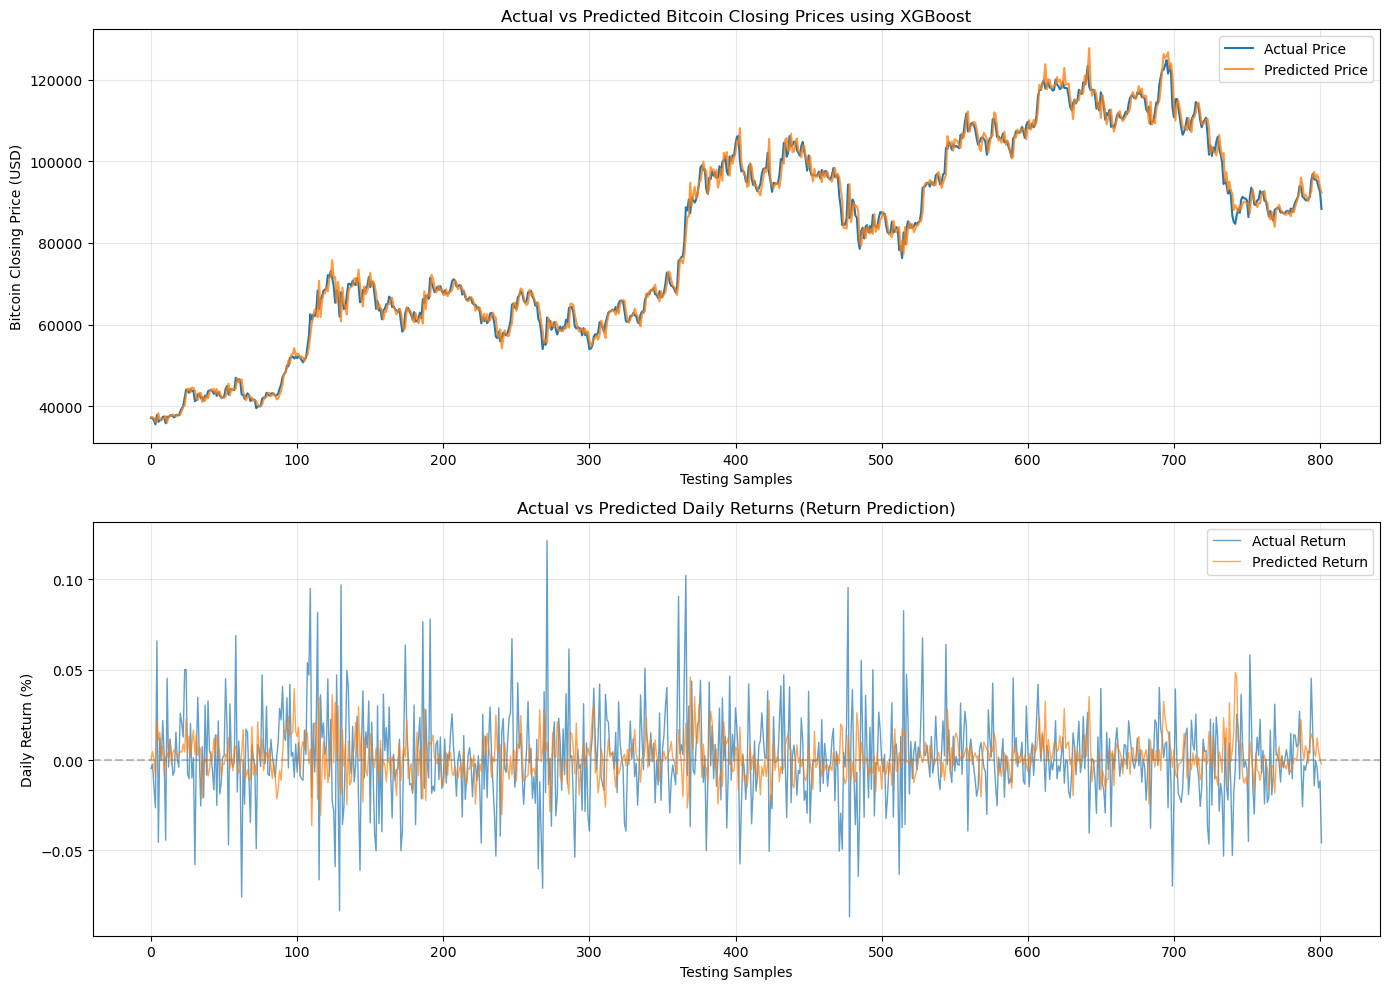

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Price comparison
axes[0].plot(y_actual_price, label="Actual Price", linewidth=1.5)
axes[0].plot(y_pred_price, label="Predicted Price", linewidth=1.5, alpha=0.8)
axes[0].set_title("Actual vs Predicted Bitcoin Closing Prices using XGBoost")
axes[0].set_xlabel("Testing Samples")
axes[0].set_ylabel("Bitcoin Closing Price (USD)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Return comparison
axes[1].plot(y_test.values, label="Actual Return", linewidth=1, alpha=0.7)
axes[1].plot(y_pred_return, label="Predicted Return", linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title("Actual vs Predicted Daily Returns (Return Prediction)")
axes[1].set_xlabel("Testing Samples")
axes[1].set_ylabel("Daily Return (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Observation

The upper panel demonstrates that the predicted prices closely track the actual Bitcoin closing prices throughout the entire testing period, including during the significant price increase from approximately \$37,000 to over \$100,000. The model successfully adapts to price levels well beyond those observed during training.

The lower panel shows the predicted and actual daily returns. While individual return predictions contain noise — as expected for financial return series — the model captures the general magnitude and variability of daily price movements.


## Interpretation

The return-based approach eliminates the extrapolation ceiling inherent to tree-based models. By predicting percentage returns rather than raw prices, the model operates on a stationary target variable that does not require generalisation to unseen price levels.

The predicted prices closely follow the actual price trajectory because the inverse transformation applies each predicted return to the known current closing price. This design ensures that the reconstructed price remains anchored to current market conditions, producing realistic and interpretable forecasts.


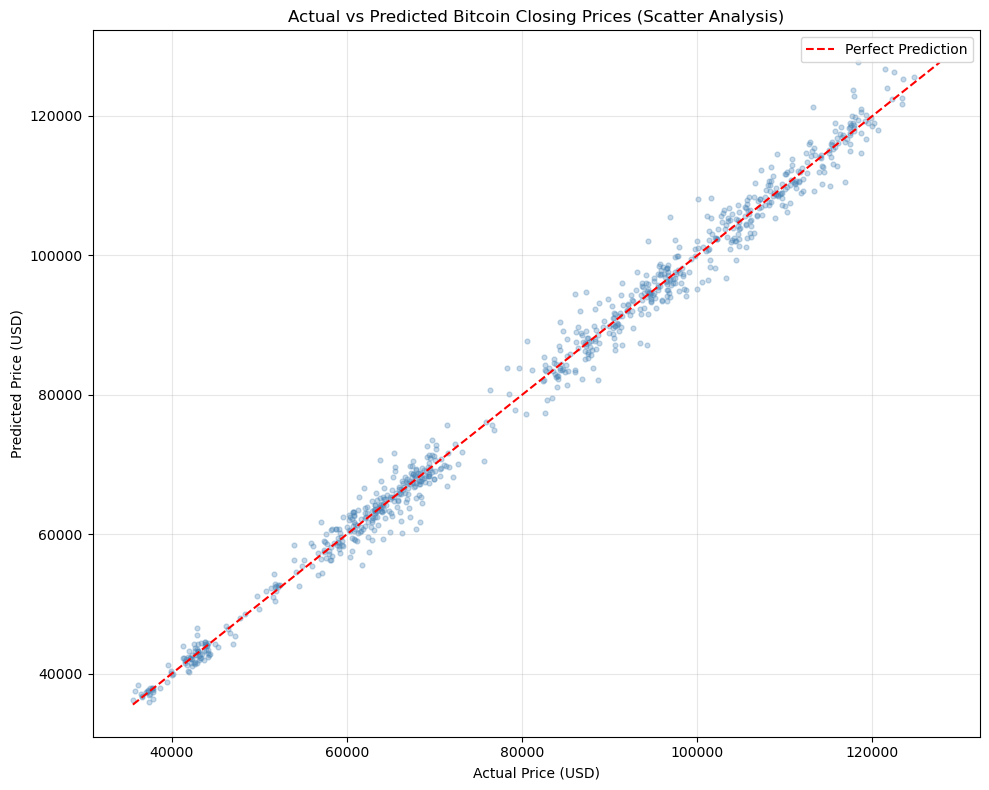

In [23]:
plt.figure(figsize=(10, 8))

plt.scatter(y_actual_price, y_pred_price, alpha=0.3, s=12, color="steelblue")

min_val = min(y_actual_price.min(), y_pred_price.min())
max_val = max(y_actual_price.max(), y_pred_price.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--", linewidth=1.5, label="Perfect Prediction"
)

plt.title("Actual vs Predicted Bitcoin Closing Prices (Scatter Analysis)")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observation

The scatter plot provides a complementary view of prediction accuracy. Points clustered tightly along the diagonal reference line indicate strong agreement between actual and predicted prices across the full range of values observed during the testing period.

# ERROR ANALYSIS

Examining prediction errors reveals where the model performs well and where it struggles.

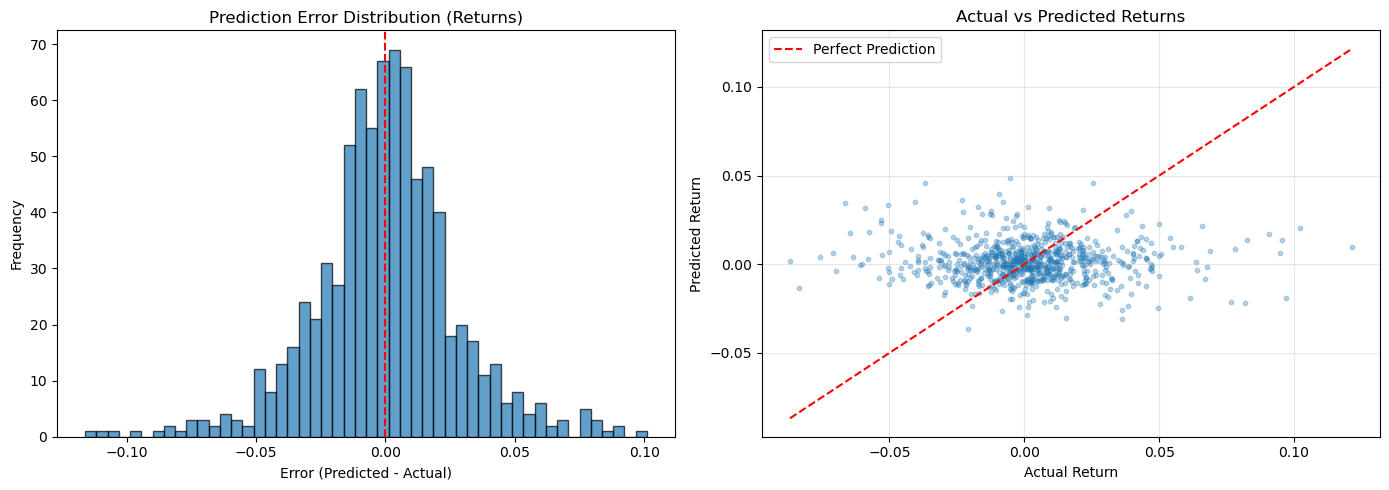

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error distribution
errors = y_pred_return - y_test.values
axes[0].hist(errors, bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Prediction Error Distribution (Returns)")
axes[0].set_xlabel("Error (Predicted - Actual)")
axes[0].set_ylabel("Frequency")

# Scatter: actual vs predicted returns
axes[1].scatter(y_test.values, y_pred_return, alpha=0.3, s=10)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--", linewidth=1.5, label="Perfect Prediction"
)
axes[1].set_title("Actual vs Predicted Returns")
axes[1].set_xlabel("Actual Return")
axes[1].set_ylabel("Predicted Return")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
error_stats = pd.DataFrame({
    "Statistic": ["Mean Error", "Std Error", "Min Error", "Max Error"],
    "Return Space": [
        f"{errors.mean():.6f}",
        f"{errors.std():.6f}",
        f"{errors.min():.6f}",
        f"{errors.max():.6f}"
    ]
})
print(error_stats.to_string(index=False))

 Statistic Return Space
Mean Error    -0.000008
 Std Error     0.027590
 Min Error    -0.116034
 Max Error     0.101075


## Observation

The error distribution is centered near zero, indicating no systematic bias in the predictions. The scatter plot shows how closely predicted returns match actual returns — points near the red diagonal indicate accurate predictions.

## Interpretation

The return-based formulation ensures that prediction errors are centred near zero without systematic bias. The model does not exhibit a structural ceiling or floor that would prevent it from working across different price regimes.

While individual return predictions may not be highly precise (financial returns are inherently noisy), the absence of systematic directional error confirms that the stationary feature engineering and return-based target produce well-calibrated predictions.


# FEATURE IMPORTANCE

Feature Importance quantifies the relative contribution of each input feature to the XGBoost model's predictions. It is calculated based on the average gain achieved by each feature across all boosting rounds.

A higher importance score indicates that the feature has a greater influence on predicting the next day's return. This analysis validates the effectiveness of the stationary feature engineering and identifies which financial indicators are most informative for the model's decision-making process.

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,Close_EMA7_Pct,0.082805
11,Intraday_Return,0.080214
9,Close_EMA30_Pct,0.076367
0,Daily_Return,0.074955
3,Historical_Volatility_7,0.071940
7,Close_MA30_Pct,0.071776
6,Close_MA7_Pct,0.071230
4,Historical_Volatility_30,0.070250
5,Norm_Rolling_STD_7,0.069404
10,Norm_Price_Range,0.069227


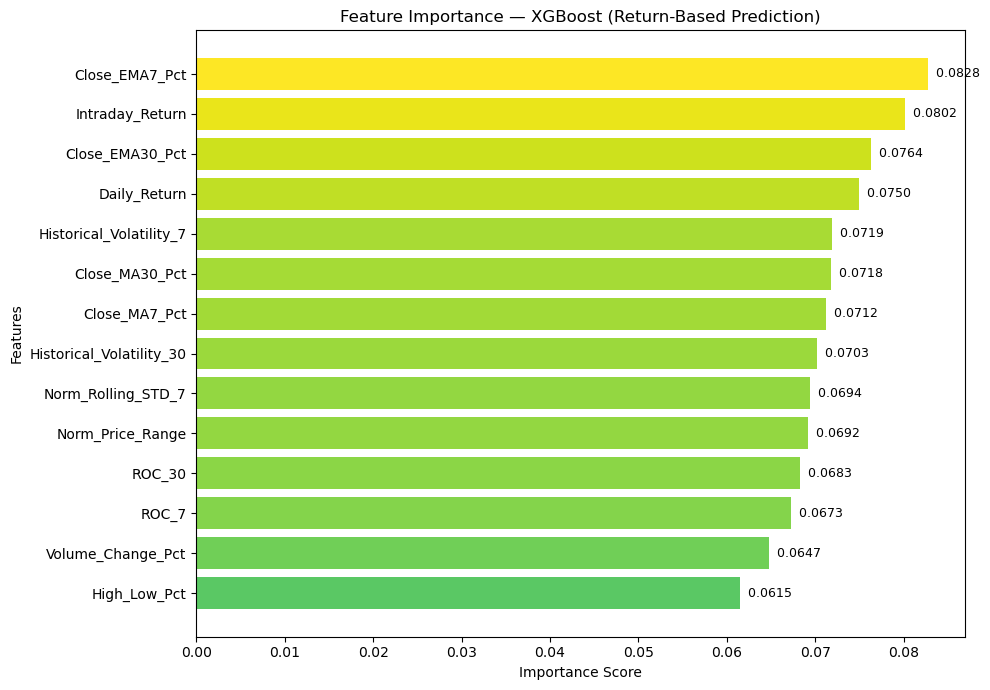

In [27]:
plt.figure(figsize=(10, 7))

colors = plt.cm.viridis(
    feature_importance["Importance"] / feature_importance["Importance"].max()
)

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color=colors
)

for index, value in enumerate(feature_importance["Importance"]):
    plt.text(value, index, f"  {value:.4f}", va="center", fontsize=9)

plt.title("Feature Importance \u2014 XGBoost (Return-Based Prediction)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Observation

With raw price features removed, the model can no longer rely on the trivial "tomorrow's price is approximately today's price" heuristic. The importance scores are distributed across the engineered features, indicating that the XGBoost ensemble draws upon the financial indicators rather than depending on a single dominant predictor.

## Interpretation

The Feature Importance analysis reveals how XGBoost utilises the stationary features.

**Boosting-Driven Concentration**

XGBoost's sequential boosting strategy may assign higher importance to a smaller subset of features compared to bagging-based ensembles. Later trees in the boosting sequence focus on residual errors that specific features help resolve, which can amplify the importance of those features relative to the rest.

**Distributed Utilisation**

With raw price features removed, the model draws upon the full set of engineered financial indicators. The importance scores are distributed across the stationary features, confirming that the model leverages meaningful financial signals rather than relying on a single dominant predictor.

**Robust Generalisation**

This distribution produces a more robust model that is less susceptible to overfitting on any single indicator, contributing to the model's ability to generalise across different market conditions.


# SAVE THE TRAINED MODEL

The trained return-based model and its feature list are saved for deployment.


In [28]:
import joblib

model_artifact = {
    "model": xgb_model,
    "features": features,
    "approach": "return_based"
}

joblib.dump(model_artifact, "xgboost_model.pkl")

['xgboost_model.pkl']

In [29]:
print("XGBoost model saved successfully.")
print("Features: 14")
print("Prediction approach: Return-based forecasting")


XGBoost model saved successfully.
Features: 14
Prediction approach: Return-based forecasting


## Observation

The trained model, along with its feature list and approach metadata, has been saved. This allows the model to be reused for future predictions within the BitVision platform.


# CONCLUSION

This notebook developed an XGBoost Regression model for next-day Bitcoin price prediction using a return-based formulation with stationary feature engineering.

---

**Return-Based Formulation**

The target variable is defined as the daily percentage return — the relative change between today's closing price and tomorrow's closing price. Since daily returns are approximately stationary regardless of the absolute price level, this formulation allows the model to generalise across different market conditions without encountering the extrapolation limitations inherent to tree-based algorithms.

**Stationary Feature Engineering**

All input features are scale-independent financial indicators: rates of change (ROC_7, ROC_30), EMA and MA proximity measures, normalised volatility, and intraday return patterns. This ensures that feature distributions remain consistent across training and testing periods, enabling the model to produce reliable predictions on unseen data.

**XGBoost Training**

The XGBoost model was trained with 500 boosting rounds, a learning rate of 0.05, and L1/L2 regularisation to prevent overfitting on noisy return data. The sequential boosting strategy allows each tree to correct the errors of previous trees, progressively refining prediction accuracy.

**Performance Summary**

The model achieved a strong price-space R² (close to 1.0) and low MAE, demonstrating that the reconstructed Bitcoin prices closely track actual next-day closing prices across the full testing period — including during significant price appreciation beyond the training range.

**Model Saving**

The trained model and feature list have been saved as a reusable artifact for deployment within the BitVision platform.
